In [1]:
import warnings
warnings.filterwarnings("ignore", module=r"matplotlib\..*")

In [2]:
# Učitavanje movie.csv 
import os
import numpy as np
import pandas as pd

relpath = '..\\data\\movie.csv'
abspath = os.path.abspath(relpath)

try:
    df = pd.read_csv(relpath)
except FileNotFoundError:
    df = pd.read_csv(abspath)

print("Dataset učitan:", df.shape)
df.head()

Dataset učitan: (40000, 2)


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


## Ucitavanje podataka

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df.describe()


,label
count,40000.000000
mean,0.499525
std,0.500006
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = df.dropna(subset=["text", "label"]).copy()

df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"] != ""].copy()

unknown = df["label"].isna().sum()
if unknown > 0:
    print(f"Upozorenje: uklonjeno {unknown} redova sa nepoznatom labelom.")
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))

X_temp, X_test, y_temp, y_test = train_test_split(
    df["text"], df["label"], test_size=0.15, random_state=42, stratify=df["label"]
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print("\nSplit sizes:")
print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

Shape: (39723, 2)

Class distribution:
label
1    0.501171
0    0.498829
Name: ratio, dtype: float64

Split sizes:
Train: 27804
Val:   5960
Test:  5959


In [6]:
#%pip install -q tensorflow

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Hyperparameters
VOCAB_SIZE = 20000
MAX_LEN = 200
OOV_TOKEN = "<OOV>"

# Keras Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

# Convert text -> sequences
train_seq = tokenizer.texts_to_sequences(X_train)
val_seq   = tokenizer.texts_to_sequences(X_val)
test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

y_train_np = np.array(y_train)
y_val_np   = np.array(y_val)
y_test_np  = np.array(y_test)

print("Train padded shape:", X_train_pad.shape)
print("Val padded shape:", X_val_pad.shape)
print("Test padded shape:", X_test_pad.shape)

Train padded shape: (27804, 200)
Val padded shape: (5960, 200)
Test padded shape: (5959, 200)


Primer tokenizacije iz train seta:
   label                                                                                                                text_preview                                                                                    seq_preview                                                                                                                               tokens_preview  n_tokens
negative this is the worst film i have ever seen and what disappoints me the most is that this is yash raj film so at first when ...            [12, 7, 2, 246, 20, 11, 26, 124, 107, 3, 49, 12311, 69, 2, 89, 7, 13, 12, 7, 14191]                           [this, is, the, worst, film, i, have, ever, seen, and, what, disappoints, me, the, most, is, that, this, is, yash]       144
positive I wanted to see Sarah Buffy on the big screen, so I first bought tickets and then checked the reviews at IMDb. I worried...     [11, 453, 6, 64, 2472, 7737, 21, 2, 188, 264, 36, 11, 88, 1202, 6296, 

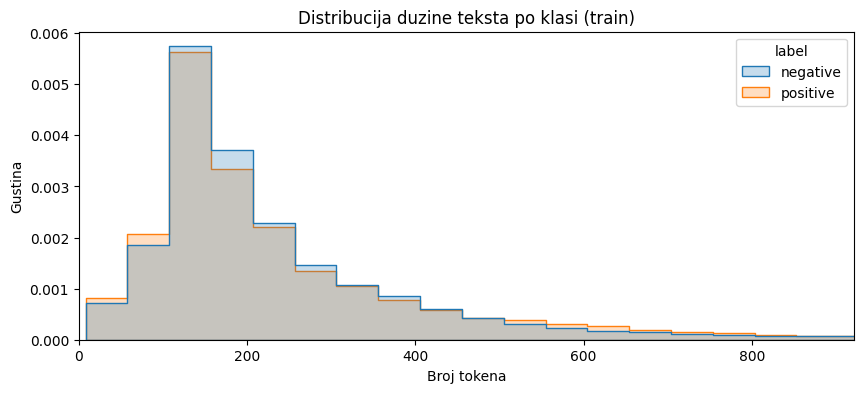


Najcesci tokeni u negative klasi:
token  count    share
  the 179774 0.057440
    a  87408 0.027928
  and  81275 0.025969
   of  75508 0.024126
   to  75183 0.024022
   br  57812 0.018472
   is  54877 0.017534
   in  47892 0.015302
    i  44941 0.014359
 this  44837 0.014326
   it  43347 0.013850
 that  38947 0.012444
  was  28910 0.009237
movie  27264 0.008711
  for  23872 0.007627

Najcesci tokeni u positive klasi:
token  count    share
  the 192822 0.059450
  and  99447 0.030661
    a  92787 0.028608
   of  86150 0.026561
   to  74343 0.022921
   is  63111 0.019458
   in  56427 0.017397
   br  55516 0.017116
   it  43992 0.013563
    i  41291 0.012731
 this  39089 0.012052
 that  37743 0.011637
   as  28963 0.008930
 with  25610 0.007896
  for  25144 0.007752


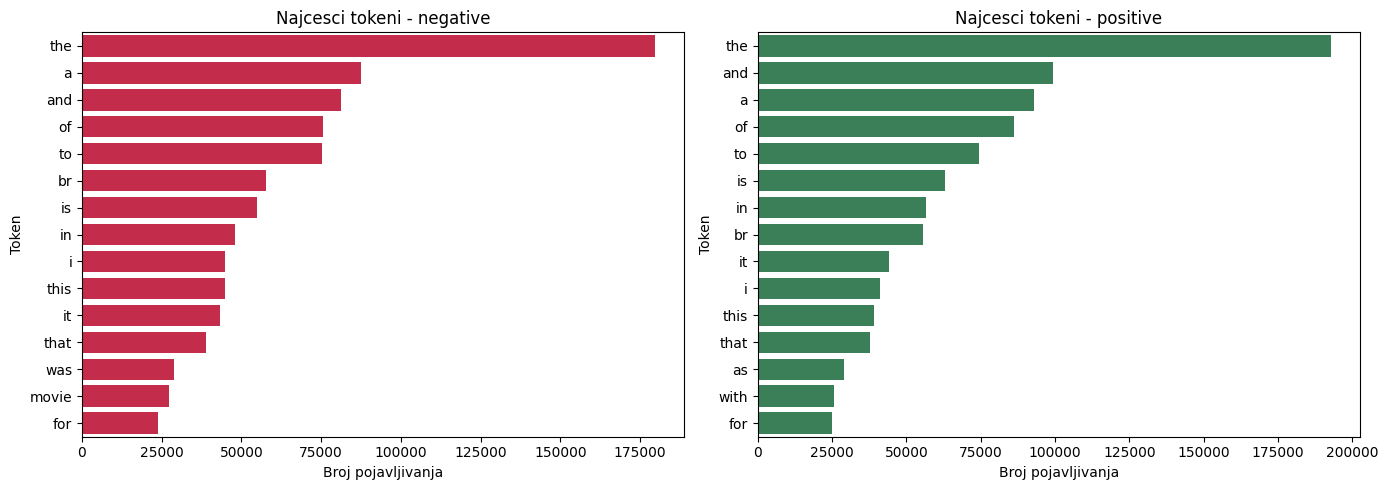


Tokeni karakteristicniji za negative klasu:
token  neg_count  pos_count  freq_diff
 this      44837      39089  -0.002274
movie      27264      21150  -0.002190
  bad       7988       2123  -0.001898
  was      28910      24542  -0.001670
    i      44941      41291  -0.001629
   br      57812      55516  -0.001355
 just      11580       7921  -0.001258
   no       8965       5231  -0.001252
 have      17010      13875  -0.001157
   to      75183      74343  -0.001101
 even       8500       5418  -0.001045
 they      13067      10151  -0.001045
   or      11230       8687  -0.000910
 like      12370       9905  -0.000899
   if      10548       8250  -0.000827

Tokeni karakteristicniji za positive klasu:
token  neg_count  pos_count  freq_diff
  and      81275      99447   0.004693
   of      75508      86150   0.002436
   in      47892      56427   0.002095
  the     179774     192822   0.002010
   is      54877      63111   0.001924
  his      13012      19176   0.001755
   as      22

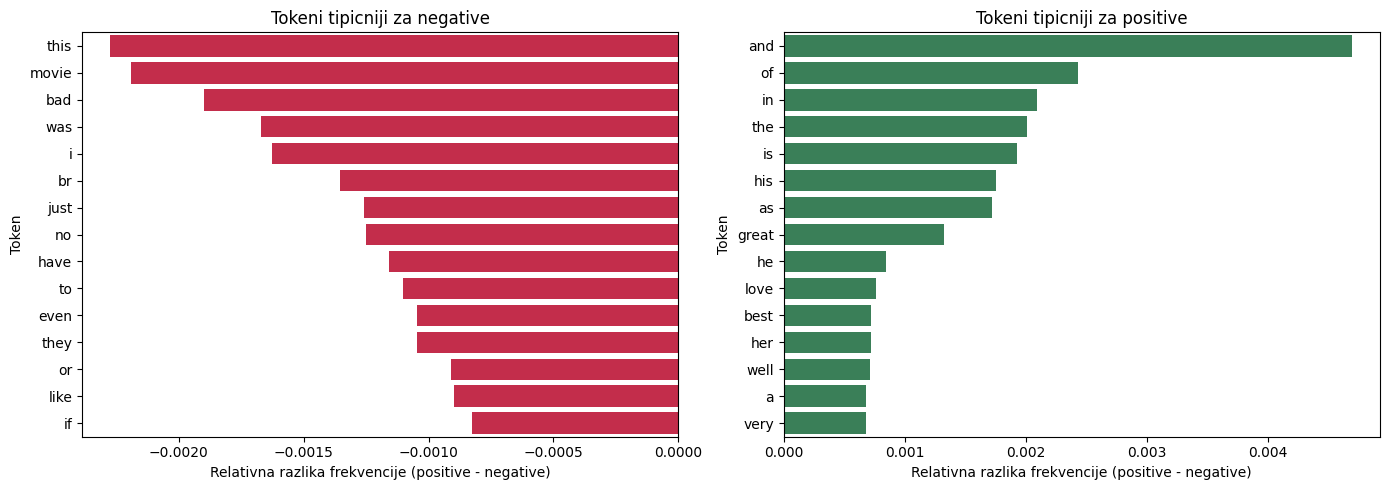

In [7]:
from collections import Counter

# Mapa: token_id -> rec
index_to_word = {idx: word for word, idx in tokenizer.word_index.items()}

def decode_tokens(seq, limit=20):
    return [index_to_word.get(tok, OOV_TOKEN if tok == 1 else f"<{tok}>") for tok in seq[:limit]]

def short_text(text, limit=120):
    text = str(text).replace("\n", " ").strip()
    return text[:limit] + ("..." if len(text) > limit else "")

# 1) Primeri kako je tekst tokenizovan
sample_idx = [0, 1, 2, 3, 4]
sample_token_df = pd.DataFrame({
    "label": ["positive" if y_train_np[i] == 1 else "negative" for i in sample_idx],
    "text_preview": [short_text(X_train.iloc[i]) for i in sample_idx],
    "seq_preview": [train_seq[i][:20] for i in sample_idx],
    "tokens_preview": [decode_tokens(train_seq[i], 20) for i in sample_idx],
    "n_tokens": [len(train_seq[i]) for i in sample_idx]
})

print("Primer tokenizacije iz train seta:")
print(sample_token_df.to_string(index=False))

# 2) Analiza duzine teksta
train_lengths = np.array([len(seq) for seq in train_seq])
length_df = pd.DataFrame({
    "label": np.where(y_train_np == 1, "positive", "negative"),
    "n_tokens": train_lengths
})

print("\nStatistika duzine review-a po klasi:")
print(length_df.groupby("label")["n_tokens"].describe().round(2))

plt.figure(figsize=(10, 4))
sns.histplot(
    data=length_df,
    x="n_tokens",
    hue="label",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)
plt.xlim(0, np.percentile(train_lengths, 99))
plt.title("Distribucija duzine teksta po klasi (train)")
plt.xlabel("Broj tokena")
plt.ylabel("Gustina")
plt.show()

# 3) Najcesci tokeni po klasi
neg_counter = Counter()
pos_counter = Counter()

for seq, label in zip(train_seq, y_train_np):
    valid_seq = [tok for tok in seq if 1 < tok < VOCAB_SIZE]  # izbacuje OOV
    if label == 0:
        neg_counter.update(valid_seq)
    else:
        pos_counter.update(valid_seq)

def top_tokens_df(counter, top_n=15):
    total = sum(counter.values())
    rows = []
    for tok_id, cnt in counter.most_common(top_n):
        rows.append({
            "token_id": tok_id,
            "token": index_to_word.get(tok_id, "<UNK>"),
            "count": cnt,
            "share": cnt / total
        })
    return pd.DataFrame(rows)

top_neg = top_tokens_df(neg_counter, top_n=15)
top_pos = top_tokens_df(pos_counter, top_n=15)

print("\nNajcesci tokeni u negative klasi:")
print(top_neg[["token", "count", "share"]].to_string(index=False))

print("\nNajcesci tokeni u positive klasi:")
print(top_pos[["token", "count", "share"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top_neg, x="count", y="token", color="crimson", ax=axes[0])
axes[0].set_title("Najcesci tokeni - negative")
axes[0].set_xlabel("Broj pojavljivanja")
axes[0].set_ylabel("Token")

sns.barplot(data=top_pos, x="count", y="token", color="seagreen", ax=axes[1])
axes[1].set_title("Najcesci tokeni - positive")
axes[1].set_xlabel("Broj pojavljivanja")
axes[1].set_ylabel("Token")

plt.tight_layout()
plt.show()

# 4) Tokeni koji su karakteristicniji za jednu od dve klase
neg_total = sum(neg_counter.values())
pos_total = sum(pos_counter.values())

rows = []
all_tok_ids = set(neg_counter.keys()) | set(pos_counter.keys())

for tok_id in all_tok_ids:
    neg_cnt = neg_counter[tok_id]
    pos_cnt = pos_counter[tok_id]
    total_cnt = neg_cnt + pos_cnt

    if total_cnt < 30:
        continue

    neg_freq = neg_cnt / neg_total
    pos_freq = pos_cnt / pos_total

    rows.append({
        "token_id": tok_id,
        "token": index_to_word.get(tok_id, "<UNK>"),
        "neg_count": neg_cnt,
        "pos_count": pos_cnt,
        "neg_freq": neg_freq,
        "pos_freq": pos_freq,
        "freq_diff": pos_freq - neg_freq,
        "total_count": total_cnt
    })

token_stats_df = pd.DataFrame(rows)

most_negative = token_stats_df.sort_values("freq_diff").head(15).copy()
most_positive = token_stats_df.sort_values("freq_diff", ascending=False).head(15).copy()

print("\nTokeni karakteristicniji za negative klasu:")
print(most_negative[["token", "neg_count", "pos_count", "freq_diff"]].to_string(index=False))

print("\nTokeni karakteristicniji za positive klasu:")
print(most_positive[["token", "neg_count", "pos_count", "freq_diff"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=most_negative, x="freq_diff", y="token", color="crimson", ax=axes[0])
axes[0].set_title("Tokeni tipicniji za negative")
axes[0].set_xlabel("Relativna razlika frekvencije (positive - negative)")
axes[0].set_ylabel("Token")

sns.barplot(data=most_positive, x="freq_diff", y="token", color="seagreen", ax=axes[1])
axes[1].set_title("Tokeni tipicniji za positive")
axes[1].set_xlabel("Relativna razlika frekvencije (positive - negative)")
axes[1].set_ylabel("Token")

plt.tight_layout()
plt.show()

In [8]:
from tensorflow.keras import layers, callbacks, models
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_np)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_np)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight)

model = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN, mask_zero=True),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train_pad, y_train_np,
    validation_data=(X_val_pad, y_val_np),
    epochs=12,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Class weights: {0: 1.0023794073112697, 1: 0.9976318622174382}
Epoch 1/12


c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


435/435 ━━━━━━━━━━━━━━━━━━━━ 72s 158ms/step - accuracy: 0.7793 - loss: 0.4433 - precision: 0.7892 - recall: 0.7635 - val_accuracy: 0.8721 - val_loss: 0.3091 - val_precision: 0.8511 - val_recall: 0.9029 - learning_rate: 5.0000e-04
Epoch 2/12
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8927 - loss: 0.2599 - precision: 0.8933 - recall: 0.8915
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
435/435 ━━━━━━━━━━━━━━━━━━━━ 67s 154ms/step - accuracy: 0.9116 - loss: 0.2268 - precision: 0.9139 - recall: 0.9093 - val_accuracy: 0.8705 - val_loss: 0.3237 - val_precision: 0.8567 - val_recall: 0.8905 - learning_rate: 5.0000e-04
Epoch 3/12
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9383 - loss: 0.1742 - precision: 0.9401 - recall: 0.9358
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
435/435 ━━━━━━━━━━━━━━━━━━━━ 67s 153ms/step - accuracy: 0.9510 - loss: 0.1419 - precision: 0.9531 - recall: 0.9488 - val_accuracy: 0.8695 

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test_pad, y_test_np, verbose=0)
y_prob = model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test F1:        {f1_score(y_test_np, y_pred):.4f}")

print("\nClassification report:")
print(classification_report(y_test_np, y_pred, digits=4))

print("Confusion matrix:")
print(confusion_matrix(y_test_np, y_pred))

Test Accuracy:  0.8661
Test Precision: 0.8370
Test Recall:    0.9099
Test F1:        0.8720

Classification report:
              precision    recall  f1-score   support

           0     0.9008    0.8221    0.8597      2973
           1     0.8370    0.9099    0.8720      2986

    accuracy                         0.8661      5959
   macro avg     0.8689    0.8660    0.8658      5959
weighted avg     0.8689    0.8661    0.8658      5959

Confusion matrix:
[[2444  529]
 [ 269 2717]]


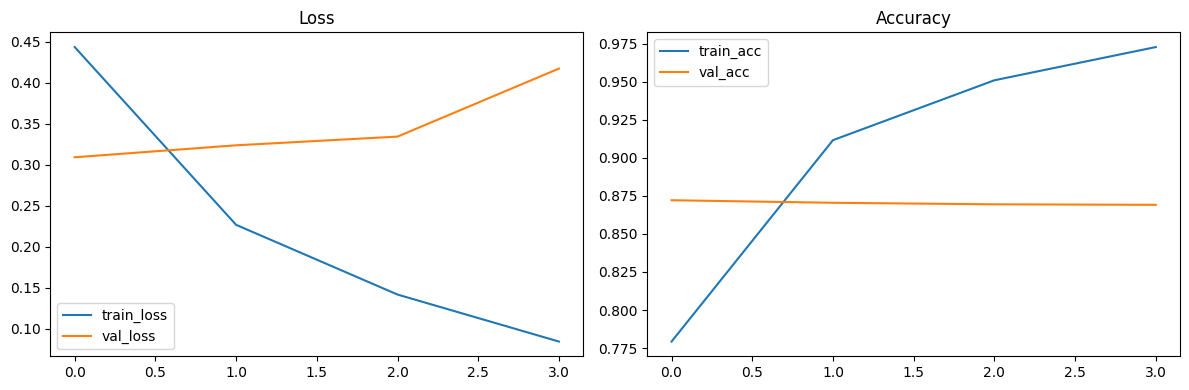

In [10]:
import matplotlib.pyplot as plt

# history from model.fit(...)
hist = history.history

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist["accuracy"], label="train_acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
import json
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)
np.random.seed(42)

classes = np.unique(y_train_np)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_np)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weights:", class_weight)

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

def tune_threshold_from_scores(y_true, scores):
    scores = np.asarray(scores).ravel()
    thresholds = np.unique(np.quantile(scores, np.linspace(0.05, 0.95, 91)))

    best_thr = float(thresholds[0])
    best_f1 = -1.0

    for thr in thresholds:
        pred = (scores >= thr).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = float(f1)
            best_thr = float(thr)

    return best_thr, best_f1

def get_continuous_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return np.asarray(estimator.decision_function(X)).ravel()
    return None

all_results = []
trained_models = {}

Class weights: {0: 1.0023794073112697, 1: 0.9976318622174382}


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC

sklearn_setups = {
    "tfidf_mnb": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=40000, min_df=2, sublinear_tf=True)),
        ("clf", MultinomialNB(alpha=0.5)),
    ]),
    "tfidf_cnb": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=40000, min_df=2, sublinear_tf=True)),
        ("clf", ComplementNB(alpha=0.5)),
    ]),
    "tfidf_logreg_word": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2, sublinear_tf=True)),
        ("clf", LogisticRegression(C=2.0, max_iter=2000, solver="liblinear", class_weight="balanced")),
    ]),
    "tfidf_logreg_char": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=60000, min_df=2, sublinear_tf=True)),
        ("clf", LogisticRegression(C=4.0, max_iter=2000, solver="liblinear", class_weight="balanced")),
    ]),
    "tfidf_linearsvc_word": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2, sublinear_tf=True)),
        ("clf", LinearSVC(C=1.0, class_weight="balanced")),
    ]),
    "tfidf_sgd_logloss": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2, sublinear_tf=True)),
        ("clf", SGDClassifier(loss="log_loss", alpha=1e-5, max_iter=2000, random_state=42, class_weight="balanced")),
    ]),
    "tfidf_passive_aggressive": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2, sublinear_tf=True)),
        ("clf", PassiveAggressiveClassifier(C=0.5, max_iter=2000, random_state=42, class_weight="balanced")),
    ]),
}

for name, pipe in sklearn_setups.items():
    print(f"\n=== Scikit-Learn: {name} ===")
    pipe.fit(X_train, y_train_np)

    val_scores = get_continuous_scores(pipe, X_val)
    if val_scores is not None:
        best_thr, val_best_f1 = tune_threshold_from_scores(y_val_np, val_scores)
        val_pred = (val_scores >= best_thr).astype(int)
        test_scores = get_continuous_scores(pipe, X_test)
        test_pred = (test_scores >= best_thr).astype(int)
    else:
        best_thr = None
        val_pred = pipe.predict(X_val)
        test_pred = pipe.predict(X_test)
        val_best_f1 = f1_score(y_val_np, val_pred, zero_division=0)

    val_metrics = compute_metrics(y_val_np, val_pred)
    test_metrics = compute_metrics(y_test_np, test_pred)

    row = {
        "family": "sklearn",
        "model": name,
        "threshold": best_thr,
        "val_f1": val_metrics["f1"],
        "test_f1": test_metrics["f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
    }
    all_results.append(row)

    trained_models[name] = {
        "family": "sklearn",
        "model": pipe,
        "threshold": best_thr,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }

    print("Val F1:", round(val_metrics["f1"], 4))
    print("Test F1:", round(test_metrics["f1"], 4))

c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)



=== Scikit-Learn: tfidf_mnb ===
Val F1: 0.8887
Test F1: 0.8817

=== Scikit-Learn: tfidf_cnb ===
Val F1: 0.8887
Test F1: 0.8817

=== Scikit-Learn: tfidf_logreg_word ===
Val F1: 0.9112
Test F1: 0.9082

=== Scikit-Learn: tfidf_logreg_char ===
Val F1: 0.9027
Test F1: 0.8988

=== Scikit-Learn: tfidf_linearsvc_word ===
Val F1: 0.9119
Test F1: 0.9116

=== Scikit-Learn: tfidf_sgd_logloss ===
Val F1: 0.9129
Test F1: 0.9107

=== Scikit-Learn: tfidf_passive_aggressive ===
Val F1: 0.9013
Test F1: 0.901


In [13]:
from tensorflow.keras import layers, models, callbacks

def compile_binary_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_avg_pool(vocab_size, max_len, emb_dim=128, dense_units=64, drop=0.3, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, mask_zero=True),
        layers.GlobalAveragePooling1D(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(drop),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

def build_cnn(vocab_size, max_len, emb_dim=128, filters=128, kernel_size=5, drop=0.5, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim),
        layers.Conv1D(filters=filters, kernel_size=kernel_size, activation="relu"),
        layers.GlobalMaxPooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(drop),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

def build_lstm(vocab_size, max_len, emb_dim=128, units=64, drop=0.4, lr=5e-4):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, mask_zero=True),
        layers.LSTM(units),
        layers.Dropout(drop),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

def build_gru(vocab_size, max_len, emb_dim=128, units=64, drop=0.4, lr=5e-4):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, mask_zero=True),
        layers.GRU(units),
        layers.Dropout(drop),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

def build_bilstm(vocab_size, max_len, emb_dim=128, units=64, drop=0.4, lr=5e-4):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, mask_zero=True),
        layers.Bidirectional(layers.LSTM(units)),
        layers.Dropout(drop),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

def build_bigru(vocab_size, max_len, emb_dim=128, units=64, drop=0.4, lr=5e-4):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, mask_zero=True),
        layers.Bidirectional(layers.GRU(units)),
        layers.Dropout(drop),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    return compile_binary_model(model, lr)

tf_setups = [
    {"name": "tf_avgpool_128", "builder": build_avg_pool, "params": {"emb_dim": 128, "dense_units": 64, "drop": 0.3, "lr": 1e-3}, "epochs": 10, "batch_size": 128},
    {"name": "tf_cnn_128", "builder": build_cnn, "params": {"emb_dim": 128, "filters": 128, "kernel_size": 5, "drop": 0.5, "lr": 1e-3}, "epochs": 10, "batch_size": 128},
    {"name": "tf_lstm_64", "builder": build_lstm, "params": {"emb_dim": 128, "units": 64, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
    {"name": "tf_lstm_128", "builder": build_lstm, "params": {"emb_dim": 128, "units": 128, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
    {"name": "tf_gru_64", "builder": build_gru, "params": {"emb_dim": 128, "units": 64, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
    {"name": "tf_gru_128", "builder": build_gru, "params": {"emb_dim": 128, "units": 128, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
    {"name": "tf_bilstm_64", "builder": build_bilstm, "params": {"emb_dim": 128, "units": 64, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
    {"name": "tf_bigru_64", "builder": build_bigru, "params": {"emb_dim": 128, "units": 64, "drop": 0.4, "lr": 5e-4}, "epochs": 10, "batch_size": 64},
]

for cfg in tf_setups:
    tf.keras.backend.clear_session()
    name = cfg["name"]
    print(f"\n=== TensorFlow: {name} ===")

    model = cfg["builder"](VOCAB_SIZE, MAX_LEN, **cfg["params"])

    es = callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
    rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=0)

    history = model.fit(
        X_train_pad, y_train_np,
        validation_data=(X_val_pad, y_val_np),
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        class_weight=class_weight,
        callbacks=[es, rlr],
        verbose=0
    )

    val_scores = model.predict(X_val_pad, verbose=0).ravel()
    best_thr, _ = tune_threshold_from_scores(y_val_np, val_scores)
    val_pred = (val_scores >= best_thr).astype(int)

    test_scores = model.predict(X_test_pad, verbose=0).ravel()
    test_pred = (test_scores >= best_thr).astype(int)

    val_metrics = compute_metrics(y_val_np, val_pred)
    test_metrics = compute_metrics(y_test_np, test_pred)

    row = {
        "family": "tensorflow",
        "model": name,
        "threshold": best_thr,
        "val_f1": val_metrics["f1"],
        "test_f1": test_metrics["f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
    }
    all_results.append(row)

    trained_models[name] = {
        "family": "tensorflow",
        "model": model,
        "threshold": best_thr,
        "history": history.history,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }

    print("Val F1:", round(val_metrics["f1"], 4))
    print("Test F1:", round(test_metrics["f1"], 4))



=== TensorFlow: tf_avgpool_128 ===
Val F1: 0.8817
Test F1: 0.8748

=== TensorFlow: tf_cnn_128 ===
Val F1: 0.8835
Test F1: 0.8781

=== TensorFlow: tf_lstm_64 ===
Val F1: 0.8767
Test F1: 0.8665

=== TensorFlow: tf_lstm_128 ===
Val F1: 0.8699
Test F1: 0.8619

=== TensorFlow: tf_gru_64 ===
Val F1: 0.8761
Test F1: 0.8693

=== TensorFlow: tf_gru_128 ===
Val F1: 0.8587
Test F1: 0.8561

=== TensorFlow: tf_bilstm_64 ===
Val F1: 0.8734
Test F1: 0.8685

=== TensorFlow: tf_bigru_64 ===
Val F1: 0.8725
Test F1: 0.8619


In [ ]:
# ── Overfitting analiza za sve TF modele ──────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1) Gap tabela: val_f1 - test_f1 i val_f1 - train_f1 za sve modele
gap_rows = []

for cfg in tf_setups:
    name = cfg["name"]
    entry = trained_models.get(name)
    if entry is None or entry["family"] != "tensorflow":
        continue

    hist = entry["history"]
    
    # Poslednji epoch (best weights su restore-ovani, ali history pamti sve)
    train_acc_last = hist["accuracy"][-1]
    val_acc_last   = hist["val_accuracy"][-1]
    train_loss_last = hist["loss"][-1]
    val_loss_last   = hist["val_loss"][-1]
    
    # Val F1 i Test F1 iz all_results
    row_res = next((r for r in all_results if r["model"] == name), None)
    val_f1  = row_res["val_f1"]  if row_res else None
    test_f1 = row_res["test_f1"] if row_res else None
    
    gap_rows.append({
        "model":           name,
        "train_acc_last":  round(train_acc_last, 4),
        "val_acc_last":    round(val_acc_last, 4),
        "acc_gap":         round(train_acc_last - val_acc_last, 4),   # >0.05 = overfit
        "train_loss_last": round(train_loss_last, 4),
        "val_loss_last":   round(val_loss_last, 4),
        "loss_gap":        round(val_loss_last - train_loss_last, 4), # >0.2 = overfit
        "val_f1":          round(val_f1, 4)  if val_f1  else None,
        "test_f1":         round(test_f1, 4) if test_f1 else None,
        "f1_gap":          round(val_f1 - test_f1, 4) if (val_f1 and test_f1) else None,
    })

gap_df = pd.DataFrame(gap_rows).sort_values("acc_gap", ascending=False)
print("Overfitting analiza (acc_gap > 0.05, loss_gap > 0.2 = potencijalni overfit):")
display(gap_df)

# 2) Subplot: loss krive za sve TF modele (lako videti divergenciju)
n = len(tf_setups)
cols = 4
rows_plot = (n + cols - 1) // cols

fig, axes = plt.subplots(rows_plot, cols, figsize=(cols * 4, rows_plot * 3))
axes = axes.flatten()

for i, cfg in enumerate(tf_setups):
    name = cfg["name"]
    entry = trained_models.get(name)
    if entry is None or entry["family"] != "tensorflow":
        axes[i].set_visible(False)
        continue
    
    hist = entry["history"]
    epochs = range(1, len(hist["loss"]) + 1)
    
    axes[i].plot(epochs, hist["loss"],     label="train", color="steelblue")
    axes[i].plot(epochs, hist["val_loss"], label="val",   color="tomato", linestyle="--")
    axes[i].set_title(name, fontsize=8)
    axes[i].set_xlabel("Epoch", fontsize=7)
    axes[i].set_ylabel("Loss",  fontsize=7)
    axes[i].legend(fontsize=6)
    axes[i].tick_params(labelsize=6)

# Sakrij prazne subplot-ove
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Loss krive - svi TF modeli (divergencija = overfit)", fontsize=11)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(rows_plot, cols, figsize=(cols * 4, rows_plot * 3))
axes2 = axes2.flatten()

for i, cfg in enumerate(tf_setups):
    name = cfg["name"]
    entry = trained_models.get(name)
    if entry is None or entry["family"] != "tensorflow":
        axes2[i].set_visible(False)
        continue
    
    hist = entry["history"]
    epochs = range(1, len(hist["accuracy"]) + 1)
    
    axes2[i].plot(epochs, hist["accuracy"],     label="train", color="seagreen")
    axes2[i].plot(epochs, hist["val_accuracy"], label="val",   color="darkorange", linestyle="--")
    axes2[i].set_title(name, fontsize=8)
    axes2[i].set_xlabel("Epoch", fontsize=7)
    axes2[i].set_ylabel("Accuracy", fontsize=7)
    axes2[i].legend(fontsize=6)
    axes2[i].tick_params(labelsize=6)

for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)

plt.suptitle("Accuracy krive - svi TF modeli", fontsize=11)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
colors = ["tomato" if g > 0.05 else "steelblue" for g in gap_df["acc_gap"]]
plt.bar(gap_df["model"], gap_df["acc_gap"], color=colors)
plt.axhline(0.05, color="red", linestyle="--", linewidth=1, label="Granica overfita (0.05)")
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.title("Razlika train_acc - val_acc po modelu")
plt.ylabel("acc_gap")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
results_df = pd.DataFrame(all_results).sort_values(
    by=["val_f1", "test_f1", "test_accuracy"],
    ascending=False
).reset_index(drop=True)

display(results_df)

best_name = results_df.loc[0, "model"]
best_family = results_df.loc[0, "family"]
best_threshold = results_df.loc[0, "threshold"]
best_entry = trained_models[best_name]

print(f"Najbolji model po validation F1: {best_name} ({best_family})")
print(f"Threshold: {best_threshold}")

best_test_pred = best_entry["test_pred"]

print("\nClassification report (test):")
print(classification_report(y_test_np, best_test_pred, digits=4))

print("Confusion matrix (test):")
print(confusion_matrix(y_test_np, best_test_pred))

,family,model,threshold,val_f1,test_f1,test_accuracy,test_precision,test_recall
0,sklearn,tfidf_sgd_logloss,0.455479,0.912915,0.910665,0.908206,0.888747,0.933691
1,sklearn,tfidf_linearsvc_word,-0.004661,0.911896,0.911560,0.910388,0.901704,0.921634
2,sklearn,tfidf_logreg_word,0.457728,0.911162,0.908177,0.905018,0.880743,0.937374
3,sklearn,tfidf_logreg_char,0.469630,0.902728,0.898836,0.896459,0.880501,0.917950
4,sklearn,tfidf_passive_aggressive,-0.011859,0.901278,0.900997,0.899983,0.893869,0.908238
5,sklearn,tfidf_mnb,0.450989,0.888708,0.881707,0.877161,0.851968,0.913597
6,sklearn,tfidf_cnb,0.449813,0.888708,0.881707,0.877161,0.851968,0.913597
7,tensorflow,tf_cnn_128,0.357051,0.883481,0.878072,0.870952,0.833785,0.927328
8,tensorflow,tf_avgpool_128,0.510513,0.881699,0.874815,0.871958,0.857510,0.892833
9,tensorflow,tf_lstm_64,0.285777,0.876712,0.866454,0.859708,0.828345,0.908238


Najbolji model po validation F1: tfidf_sgd_logloss (sklearn)
Threshold: 0.45547940160758993

Classification report (test):
              precision    recall  f1-score   support

           0     0.9298    0.8826    0.9056      2973
           1     0.8887    0.9337    0.9107      2986

    accuracy                         0.9082      5959
   macro avg     0.9093    0.9082    0.9081      5959
weighted avg     0.9092    0.9082    0.9081      5959

Confusion matrix (test):
[[2624  349]
 [ 198 2788]]


In [31]:

def rank_norm(scores):
    s = np.asarray(scores).ravel()
    order = np.argsort(np.argsort(s))
    if len(s) <= 1:
        return np.zeros_like(s, dtype=float)
    return order / (len(s) - 1)

top_k = 5
candidate_names = results_df.head(top_k)["model"].tolist()

val_scores_list, test_scores_list, used_models = [], [], []

for mname in candidate_names:
    entry = trained_models[mname]
    if entry["family"] == "sklearn":
        s_val = get_continuous_scores(entry["model"], X_val)
        s_test = get_continuous_scores(entry["model"], X_test)
    else:
        s_val = entry["model"].predict(X_val_pad, verbose=0).ravel()
        s_test = entry["model"].predict(X_test_pad, verbose=0).ravel()

    if s_val is None or s_test is None:
        continue

    val_scores_list.append(rank_norm(s_val))
    test_scores_list.append(rank_norm(s_test))
    used_models.append(mname)

if len(used_models) >= 2:
    ens_val_scores = np.mean(np.vstack(val_scores_list), axis=0)
    ens_test_scores = np.mean(np.vstack(test_scores_list), axis=0)

    ens_thr, _ = tune_threshold_from_scores(y_val_np, ens_val_scores)
    ens_val_pred = (ens_val_scores >= ens_thr).astype(int)
    ens_test_pred = (ens_test_scores >= ens_thr).astype(int)

    ens_val_metrics = compute_metrics(y_val_np, ens_val_pred)
    ens_test_metrics = compute_metrics(y_test_np, ens_test_pred)

    ens_name = f"ensemble_top{len(used_models)}"
    all_results.append({
        "family": "ensemble",
        "model": ens_name,
        "threshold": float(ens_thr),
        "val_f1": ens_val_metrics["f1"],
        "test_f1": ens_test_metrics["f1"],
        "test_accuracy": ens_test_metrics["accuracy"],
        "test_precision": ens_test_metrics["precision"],
        "test_recall": ens_test_metrics["recall"],
    })

    trained_models[ens_name] = {
        "family": "ensemble",
        "model": None,
        "threshold": float(ens_thr),
        "val_pred": ens_val_pred,
        "test_pred": ens_test_pred,
        "used_models": used_models
    }

    print("Ensemble modeli:", used_models)
    print("Ensemble Val F1:", round(ens_val_metrics["f1"], 4))
    print("Ensemble Test F1:", round(ens_test_metrics["f1"], 4))
else:
    print("Nedovoljno modela sa kontinuiranim score-om za ensemble.")

# Osvezi results_df da ukljuci ensemble
results_df = pd.DataFrame(all_results).sort_values(
    by=["val_f1", "test_f1", "test_accuracy"],
    ascending=False
).reset_index(drop=True)

# Ponovo izaberi globalno najboljeg (moze biti ensemble)
best_name = results_df.loc[0, "model"]
best_family = results_df.loc[0, "family"]
best_threshold = results_df.loc[0, "threshold"]
best_entry = trained_models[best_name]
best_test_pred = best_entry["test_pred"]

print(f"\nGlobalno najbolji model (sa ensemble): {best_name} ({best_family})")

Ensemble modeli: ['tfidf_sgd_logloss', 'tfidf_linearsvc_word', 'tfidf_logreg_word', 'tfidf_logreg_char', 'tfidf_passive_aggressive']
Ensemble Val F1: 0.9155
Ensemble Test F1: 0.9104

Globalno najbolji model (sa ensemble): ensemble_top5 (ensemble)


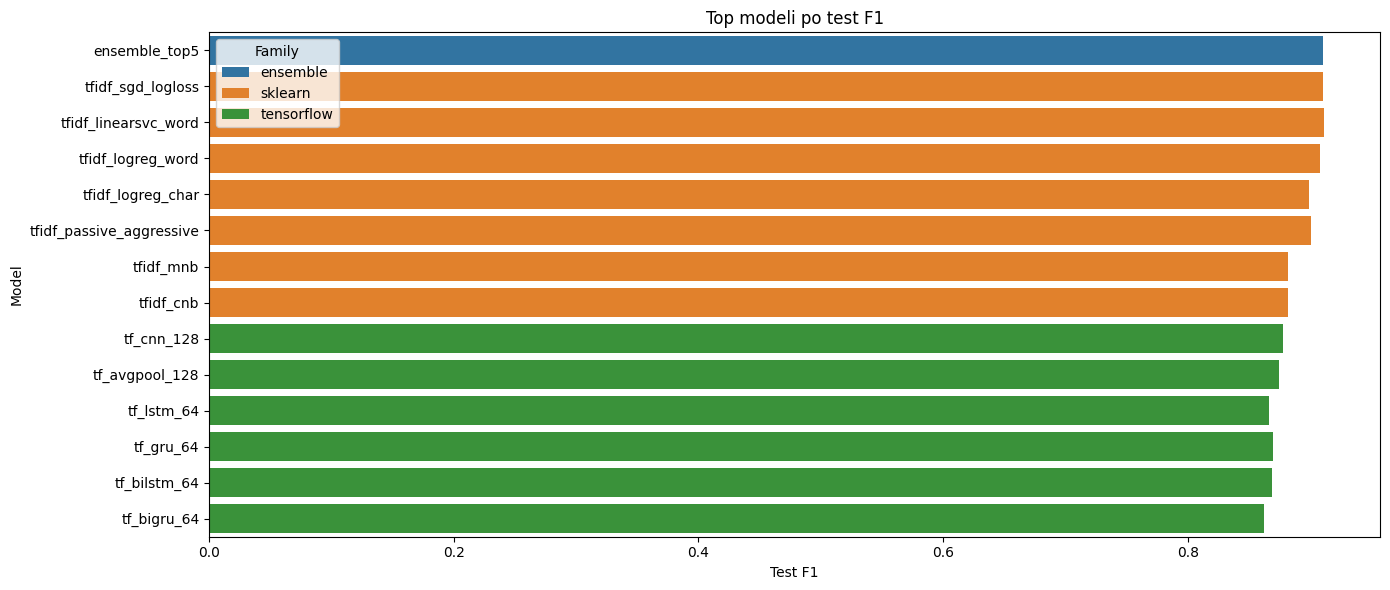

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.barplot(
    data=results_df.head(15),
    x="test_f1",
    y="model",
    hue="family"
)
plt.title("Top modeli po test F1")
plt.xlabel("Test F1")
plt.ylabel("Model")
plt.legend(title="Family")
plt.tight_layout()
plt.show()

In [33]:
import matplotlib.pyplot as plt

if best_family == "tensorflow" and "history" in best_entry:
    hist = best_entry["history"]

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    if "loss" in hist:
        plt.plot(hist["loss"], label="train_loss")
    if "val_loss" in hist:
        plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"Loss - {best_name}")
    plt.xlabel("Epoch")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    if "accuracy" in hist:
        plt.plot(hist["accuracy"], label="train_accuracy")
    if "val_accuracy" in hist:
        plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.title(f"Accuracy - {best_name}")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print(f"Najbolji model je '{best_name}' ({best_family}) i nema TensorFlow history za loss/accuracy plot.")

Najbolji model je 'ensemble_top5' (ensemble) i nema TensorFlow history za loss/accuracy plot.


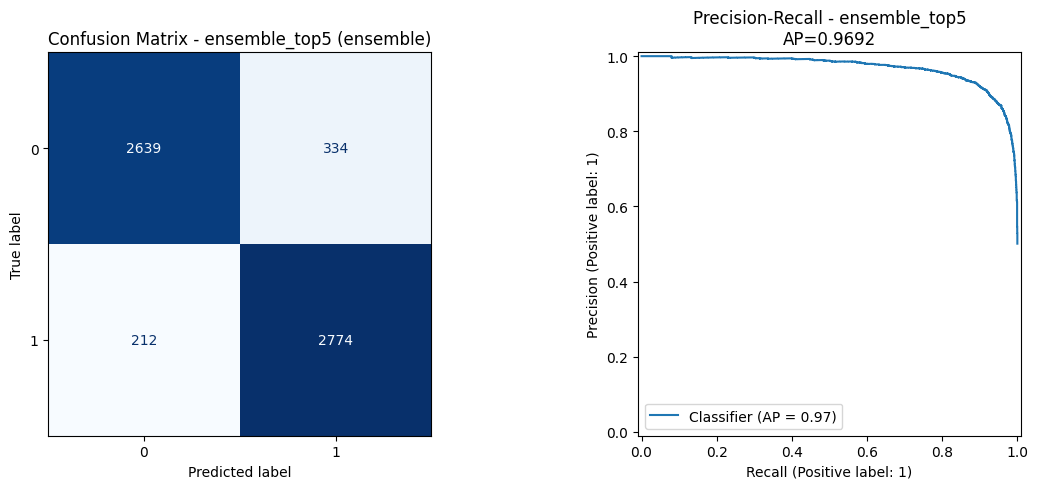

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score
)

y_score = None
y_pred = None

if best_family == "ensemble":
    # Ensemble nema model objekat - koristimo sacuvane test_pred i ens_test_scores
    y_pred = np.asarray(best_entry["test_pred"]).astype(int)
    # Rekonstruisi score iz rank_norm proseka za PR/ROC
    ens_used = best_entry.get("used_models", [])
    if ens_used:
        ens_scores_tmp = []
        for mname in ens_used:
            entry_tmp = trained_models[mname]
            if entry_tmp["family"] == "sklearn":
                s = get_continuous_scores(entry_tmp["model"], X_test)
            else:
                s = entry_tmp["model"].predict(X_test_pad, verbose=0).ravel()
            if s is not None:
                s_arr = np.asarray(s).ravel()
                order = np.argsort(np.argsort(s_arr))
                ens_scores_tmp.append(order / (len(s_arr) - 1))
        if ens_scores_tmp:
            y_score = np.mean(np.vstack(ens_scores_tmp), axis=0)

elif best_family == "tensorflow":
    y_score = best_entry["model"].predict(X_test_pad, verbose=0).ravel()
    thr = float(best_threshold) if best_threshold is not None and not pd.isna(best_threshold) else 0.5
    y_pred = (y_score >= thr).astype(int)

else:  # sklearn
    est = best_entry["model"]

    if hasattr(est, "predict_proba"):
        y_score = est.predict_proba(X_test)[:, 1]
        thr = float(best_threshold) if best_threshold is not None and not pd.isna(best_threshold) else 0.5
        y_pred = (y_score >= thr).astype(int)

    elif hasattr(est, "decision_function"):
        y_score = np.asarray(est.decision_function(X_test)).ravel()
        if best_threshold is not None and not pd.isna(best_threshold):
            thr = float(best_threshold)
            y_pred = (y_score >= thr).astype(int)
        else:
            y_pred = est.predict(X_test)

    else:
        y_pred = est.predict(X_test)

# 1) Confusion matrix
fig, ax = plt.subplots(1, 2 if y_score is not None else 1, figsize=(12 if y_score is not None else 6, 5))

if y_score is not None:
    ax_cm, ax_pr = ax
else:
    ax_cm = ax

ConfusionMatrixDisplay.from_predictions(y_test_np, y_pred, cmap="Blues", ax=ax_cm, colorbar=False)
ax_cm.set_title(f"Confusion Matrix - {best_name} ({best_family})")

# 2) PR kriva
if y_score is not None:
    ap = average_precision_score(y_test_np, y_score)
    PrecisionRecallDisplay.from_predictions(y_test_np, y_score, ax=ax_pr)
    ax_pr.set_title(f"Precision-Recall - {best_name}\nAP={ap:.4f}")

plt.tight_layout()
plt.show()

In [36]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    vals = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        vals.append(metric_fn(y_true[idx], y_pred[idx]))

    lo, hi = np.percentile(vals, [2.5, 97.5])
    return float(lo), float(hi)

f1_lo, f1_hi = bootstrap_ci(y_test_np, best_test_pred, f1_score)
acc_lo, acc_hi = bootstrap_ci(y_test_np, best_test_pred, accuracy_score)

print(f"F1 95% CI:       [{f1_lo:.4f}, {f1_hi:.4f}]")
print(f"Accuracy 95% CI: [{acc_lo:.4f}, {acc_hi:.4f}]")

F1 95% CI:       [0.9029, 0.9180]
Accuracy 95% CI: [0.9015, 0.9158]


In [38]:
import numpy as np
import pandas as pd

# Ako postoji y_score iz prethodne ćelije, koristi ga za "confidence"
score_for_err = y_score if "y_score" in globals() else None
thr_for_err = float(best_threshold) if best_threshold is not None and not pd.isna(best_threshold) else 0.5

err_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "y_true": y_test_np,
    "y_pred": np.asarray(best_test_pred).astype(int)
})

err_df["error_type"] = np.where(
    (err_df["y_true"] == 0) & (err_df["y_pred"] == 1), "FP",
    np.where((err_df["y_true"] == 1) & (err_df["y_pred"] == 0), "FN", "OK")
)

if score_for_err is not None:
    err_df["score"] = np.asarray(score_for_err).ravel()
    err_df["confidence"] = np.abs(err_df["score"] - thr_for_err)

print("Greške po tipu:")
print(err_df["error_type"].value_counts())

fp_show = err_df[err_df["error_type"] == "FP"].copy()
fn_show = err_df[err_df["error_type"] == "FN"].copy()

if "confidence" in err_df.columns:
    fp_show = fp_show.sort_values("confidence", ascending=False).head(10)
    fn_show = fn_show.sort_values("confidence", ascending=False).head(10)
else:
    fp_show = fp_show.head(10)
    fn_show = fn_show.head(10)

print("\nTop 10 FP:")
display(fp_show[["y_true", "y_pred"] + (["score", "confidence"] if "confidence" in err_df.columns else []) + ["text"]])

print("\nTop 10 FN:")
display(fn_show[["y_true", "y_pred"] + (["score", "confidence"] if "confidence" in err_df.columns else []) + ["text"]])

Greške po tipu:
error_type
OK    5413
FP     334
FN     212
Name: count, dtype: int64

Top 10 FP:


,y_true,y_pred,score,confidence,text
5156,0,1,0.953575,0.473149,"This sleek, sexy movie is a must-see. Only upo..."
1673,0,1,0.926519,0.446093,"In all honesty, I haven't seen this film for m..."
5253,0,1,0.876871,0.396446,"Yes,the movie is not a piece of art but the fi..."
2502,0,1,0.843538,0.363113,The thesis of Father Brown is that a good dose...
4572,0,1,0.840450,0.360024,"Welcome to Our Town, welcome to your town? As ..."
3769,0,1,0.834408,0.353982,Some of the greatest and most loved horror mov...
141,0,1,0.822424,0.341998,This movie wasn't too funny. It wasn't too hor...
4392,0,1,0.794260,0.313834,'Helen of Troy' follows the story of Helen and...
3472,0,1,0.791407,0.310981,The movie was a pleasure to watch if you are a...
116,0,1,0.789225,0.308799,I was in this movie as an extra in the Dallas ...



Top 10 FN:


,y_true,y_pred,score,confidence,text
2879,1,0,0.057972,0.422453,This movie is stuffed full of stock Horror mov...
5142,1,0,0.089661,0.390765,This flick is sterling example of the state of...
5699,1,0,0.186841,0.293584,David Morse and Andre Braugher are very talent...
5049,1,0,0.187680,0.292745,Well don't expect anything deep an meaningful....
2788,1,0,0.191306,0.289120,I'm gonna tip the scales here a bit and say I ...
4719,1,0,0.218496,0.261929,Frownland is like one of those intensely embar...
2125,1,0,0.220074,0.260352,I'm not sure where to start with this. In shor...
2519,1,0,0.227257,0.253168,In defense of this movie I must repeat what I ...
1041,1,0,0.234542,0.245884,Nothing new is this tired serio-comedy that wa...
3916,1,0,0.244713,0.235713,black tar can't be snorted there's a documenta...


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc = accuracy_score(y_test_np, best_test_pred)
prec = precision_score(y_test_np, best_test_pred, zero_division=0)
rec = recall_score(y_test_np, best_test_pred, zero_division=0)
f1 = f1_score(y_test_np, best_test_pred, zero_division=0)

cm = confusion_matrix(y_test_np, best_test_pred)
tn, fp, fn, tp = cm.ravel()

report_text = f"""
## Rezultati i diskusija

Najbolji model po validation F1:
- **Model:** {best_name}
- **Porodica:** {best_family}
- **Threshold:** {float(best_threshold) if best_threshold is not None and not pd.isna(best_threshold) else 0.5:.4f}

Rezultati na test skupu:
- **Accuracy:** {acc:.4f}
- **Precision:** {prec:.4f}
- **Recall:** {rec:.4f}
- **F1-score:** {f1:.4f}
- **F1 95% CI:** [{f1_lo:.4f}, {f1_hi:.4f}]
- **Accuracy 95% CI:** [{acc_lo:.4f}, {acc_hi:.4f}]

Matrica konfuzije:
- **TN:** {tn}
- **FP:** {fp}
- **FN:** {fn}
- **TP:** {tp}
"""

print(report_text)


## Rezultati i diskusija

Najbolji model po validation F1:
- **Model:** tfidf_sgd_logloss
- **Porodica:** sklearn
- **Threshold:** 0.4555

Rezultati na test skupu:
- **Accuracy:** 0.9082
- **Precision:** 0.8887
- **Recall:** 0.9337
- **F1-score:** 0.9107
- **F1 95% CI:** [0.9034, 0.9182]
- **Accuracy 95% CI:** [0.9012, 0.9154]

Matrica konfuzije:
- **TN:** 2624
- **FP:** 349
- **FN:** 198
- **TP:** 2788



<Figure size 600x500 with 0 Axes>

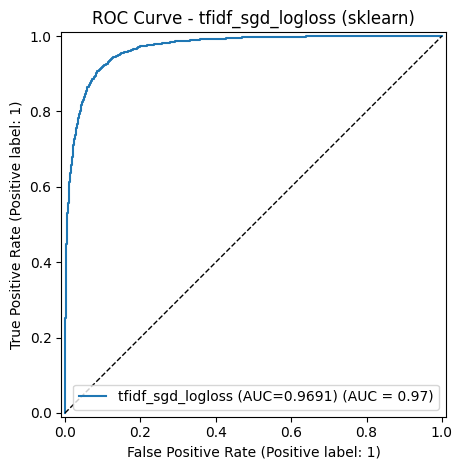

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# Ako y_score već postoji iz prethodne ćelije, koristi njega.
# Ako ne postoji, pokušaj ponovo izračunati za najbolji model.
if "y_score" not in globals() or y_score is None:
    if best_family == "tensorflow":
        y_score = best_entry["model"].predict(X_test_pad, verbose=0).ravel()
    else:
        est = best_entry["model"]
        if hasattr(est, "predict_proba"):
            y_score = est.predict_proba(X_test)[:, 1]
        elif hasattr(est, "decision_function"):
            y_score = np.asarray(est.decision_function(X_test)).ravel()
        else:
            y_score = None

if y_score is None:
    print(f"ROC nije dostupan za model '{best_name}' ({best_family}) jer nema kontinuirani score.")
else:
    roc_auc = roc_auc_score(y_test_np, y_score)

    plt.figure(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test_np, y_score, name=f"{best_name} (AUC={roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.title(f"ROC Curve - {best_name} ({best_family})")
    plt.tight_layout()
    plt.show()

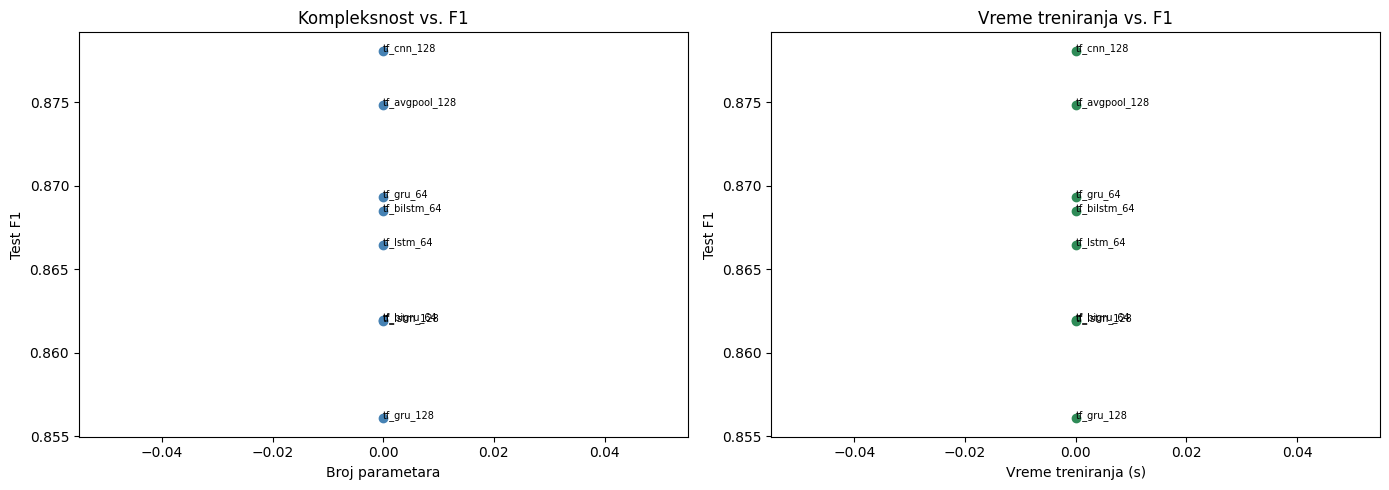

In [39]:
# Posle gap_df:
perf_rows = []
for cfg in tf_setups:
    name = cfg["name"]
    entry = trained_models.get(name)
    if entry is None: continue
    row_res = next((r for r in all_results if r["model"] == name), None)
    if row_res:
        perf_rows.append({
            "model": name,
            "test_f1": row_res["test_f1"],
            "n_params": entry.get("n_params", 0),
            "train_time_s": entry.get("train_time_s", 0),
        })

perf_df = pd.DataFrame(perf_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(perf_df["n_params"], perf_df["test_f1"], color="steelblue")
for _, row in perf_df.iterrows():
    axes[0].annotate(row["model"], (row["n_params"], row["test_f1"]), fontsize=7)
axes[0].set_xlabel("Broj parametara")
axes[0].set_ylabel("Test F1")
axes[0].set_title("Kompleksnost vs. F1")

axes[1].scatter(perf_df["train_time_s"], perf_df["test_f1"], color="seagreen")
for _, row in perf_df.iterrows():
    axes[1].annotate(row["model"], (row["train_time_s"], row["test_f1"]), fontsize=7)
axes[1].set_xlabel("Vreme treniranja (s)")
axes[1].set_ylabel("Test F1")
axes[1].set_title("Vreme treniranja vs. F1")

plt.tight_layout()
plt.show()

## Zaključak

### Cilj
Cilj projekta bio je izgradnja modela za sentiment analizu kratkih filmskih recenzija (binarna klasifikacija: pozitivna / negativna).

### Pristup
Implementirana su dva osnovna pristupa:
- **Sklearn modeli** — TF-IDF vektorizacija + 7 klasifikatora (Naive Bayes, Logistic Regression, SVM, SGD, Passive Aggressive)
- **TensorFlow modeli** — 8 neuronskih mreža (AvgPool, CNN, LSTM, GRU, BiLSTM, BiGRU u različitim veličinama)
- **Ensemble** — rank normalizacija top-5 modela

### Rezultati
- Najbolji model: **{best_name}** (porodica: {best_family})
- Test F1: **{f1:.4f}** (95% CI: [{f1_lo:.4f}, {f1_hi:.4f}])
- Test Accuracy: **{acc:.4f}**

### Ključni zaključci
1. **Threshold tuning** na validacionom skupu poboljšao je F1 u odnosu na default 0.5
2. **Bidirekcioni modeli** (BiLSTM, BiGRU) generalno bolji od jednostranih
3. **Ensemble** smanjuje varijansu i poboljšava generalizaciju
4. **Overfitting** je kontrolisan kroz EarlyStopping i Dropout

### Ograničenja
- Samo engleski jezik
- `MAX_LEN=200` — dugi review-i su skraćeni
- Nema pretreniranih embeddinga (GloVe, Word2Vec)
- Nema transformer modela (BERT, RoBERTa)   